In [ ]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
BASE_DIR = Path("/shared/data_zfs/blue2959/ND_Aligner/experiments/v1.4_ablation/test")

FULL_DIR = BASE_DIR / "v1.4_vctk+full"
FULL_CSV = FULL_DIR / "eval_metrics.csv"

CONV_PATTERN = "v1.4_vctk+conv-RF=*"
TEXT_PATTERN = "v1.4_vctk+text-RF=*"
DEC_PATTERN = "v1.4_vctk+dec-RF=*"


In [ ]:
def read_metrics(csv_path: Path) -> dict[str, float]:
    """Read WBE and P25 from eval_metrics.csv."""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    required_cols = ["word_boundary_error", "p_word_25ms"]
    for col in required_cols:
        if col not in df.columns:
            raise KeyError(
                f"'{col}' not found in {csv_path}. "
                + f"Available columns: {list(df.columns)}"
            )

    wbe_ms = float(df["word_boundary_error"].iloc[0]) * 1000.0
    p25 = float(df["p_word_25ms"].iloc[0])

    # p_word_25ms가 0~1 ratio로 저장된 경우 percent로 변환
    if p25 <= 1.0:
        p25 *= 100.0

    return {
        "wbe_ms": wbe_ms,
        "p25": p25,
    }


def parse_rf_from_name(path: Path) -> int:
    """Parse RF value from directory name like v1.4_vctk+conv-RF=7."""
    match = re.search(r"RF=(\d+)", path.name)
    if match is None:
        raise ValueError(f"Cannot parse RF from {path.name}")
    return int(match.group(1))


def rf_to_num_layers(rf: int) -> int:
    """
    RF=3 -> 1
    RF=5 -> 2
    RF=7 -> 3
    ...
    Assumes kernel size 3, so RF = 2 * num_layers + 1.
    """
    return (rf - 1) // 2

In [ ]:
full_metrics = read_metrics(FULL_CSV)
full_wbe_ms = full_metrics["wbe_ms"]
full_p25 = full_metrics["p25"]

print(f"Full ND-Aligner WBE: {full_wbe_ms:.3f} ms")
print(f"Full ND-Aligner P25: {full_p25:.2f}")

records = []

for family, pattern in [
    ("Conv scorer", CONV_PATTERN),
    ("Text encoder", TEXT_PATTERN),
    ("Decoder", DEC_PATTERN),
]:
    for exp_dir in sorted(BASE_DIR.glob(pattern), key=lambda p: parse_rf_from_name(p)):
        csv_path = exp_dir / "eval_metrics.csv"
        if not csv_path.exists():
            print(f"[skip] missing eval_metrics.csv: {exp_dir}")
            continue

        rf = parse_rf_from_name(exp_dir)
        num_layers = rf_to_num_layers(rf)

        metrics = read_metrics(csv_path)
        wbe_ms = metrics["wbe_ms"]
        p25 = metrics["p25"]

        records.append({
            "family": family,
            "rf": rf,
            "num_layers": num_layers,
            "effective_rf": rf,
            "wbe_ms": wbe_ms,
            "p25": p25,
            "delta_wbe_ms": wbe_ms - full_wbe_ms,
            "delta_p25": p25 - full_p25,
            "path": str(exp_dir),
        })

df = pd.DataFrame(records)
df = df.sort_values(["family", "num_layers"]).reset_index(drop=True)
df

Full ND-Aligner WBE: 22.194 ms
Full ND-Aligner P25: 72.09


,family,rf,num_layers,effective_rf,wbe_ms,p25,delta_wbe_ms,delta_p25,path
0,Conv scorer,1,0,1,40.775500,59.182674,18.581072,-12.908310,/shared/data_zfs/blue2959/ND_Aligner/experimen...
1,Conv scorer,3,1,3,29.186489,65.126878,6.992061,-6.964105,/shared/data_zfs/blue2959/ND_Aligner/experimen...
2,Conv scorer,5,2,5,27.235795,67.843121,5.041366,-4.247862,/shared/data_zfs/blue2959/ND_Aligner/experimen...
3,Conv scorer,7,3,7,25.319520,70.065188,3.125092,-2.025795,/shared/data_zfs/blue2959/ND_Aligner/experimen...
4,Conv scorer,9,4,9,26.241370,70.618951,4.046941,-1.472032,/shared/data_zfs/blue2959/ND_Aligner/experimen...
5,Conv scorer,11,5,11,23.967834,69.238049,1.773406,-2.852935,/shared/data_zfs/blue2959/ND_Aligner/experimen...
6,Conv scorer,13,6,13,22.194428,72.090983,0.000000,0.000000,/shared/data_zfs/blue2959/ND_Aligner/experimen...
7,Conv scorer,15,7,15,23.556231,68.866533,1.361802,-3.224450,/shared/data_zfs/blue2959/ND_Aligner/experimen...
8,Decoder,1,0,1,24.559531,67.135149,2.365103,-4.955834,/shared/data_zfs/blue2959/ND_Aligner/experimen...
9,Decoder,3,1,3,24.049874,69.213516,1.855446,-2.877468,/shared/data_zfs/blue2959/ND_Aligner/experimen...


/tmp/ipykernel_1113923/3536512665.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


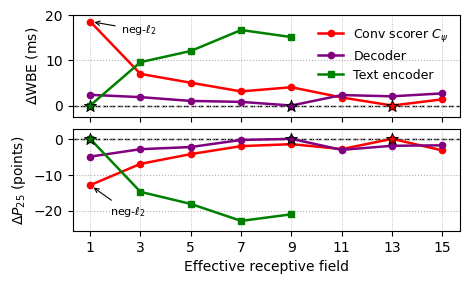

In [ ]:
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 10,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

fig, (ax_wbe, ax_p25) = plt.subplots(
    2,
    1,
    figsize=(5.0, 2.8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12},
)

style = {
    "Conv scorer": {
        "color": "red",
        "marker": "o",
        "label": r"Conv scorer $C_\psi$",
    },
    "Text encoder": {
        "color": "green",
        "marker": "s",
        "label": "Text encoder",
    },
    "Decoder": {
        "color": "purple",
        "marker": "o",
        "label": "Decoder",
    },
}

for family, group in df.groupby("family"):
    group = group.sort_values("effective_rf")

    ax_wbe.plot(
        group["effective_rf"],
        group["delta_wbe_ms"],
        color=style[family]["color"],
        marker=style[family]["marker"],
        linewidth=1.8,
        markersize=4.5,
        label=style[family]["label"],
        zorder=3,
    )

    ax_p25.plot(
        group["effective_rf"],
        group["delta_p25"],
        color=style[family]["color"],
        marker=style[family]["marker"],
        linewidth=1.8,
        markersize=4.5,
        label=style[family]["label"],
        zorder=3,
    )

# Current setting stars:
# Full ND-Aligner uses Conv scorer RF=13 and Text encoder RF=1.
current_settings = [
    ("Conv scorer", 13),
    ("Text encoder", 1),
    ("Decoder", 9),
]

for family, target_rf in current_settings:
    matched = df[(df["family"] == family) & (df["rf"] == target_rf)]

    if matched.empty:
        print(f"[warn] current setting not found: {family}, RF={target_rf}")
        continue

    row = matched.iloc[0]
    x = row["effective_rf"]
    color = style[family]["color"]

    ax_wbe.scatter(
        x,
        row["delta_wbe_ms"],
        marker="*",
        s=80,
        color=color,
        edgecolors="black",
        linewidths=0.7,
        zorder=6,
    )

    ax_p25.scatter(
        x,
        row["delta_p25"],
        marker="*",
        s=80,
        color=color,
        edgecolors="black",
        linewidths=0.7,
        zorder=6,
    )

# Mark RF=1 of Conv scorer as the negative-l2 distance baseline.
# Mark RF=1 of Conv scorer as the negative-l2 distance baseline.
neg_l2 = df[(df["family"] == "Conv scorer") & (df["rf"] == 1)]

if neg_l2.empty:
    print("[warn] negative-l2 baseline not found: Conv scorer, RF=1")
else:
    row = neg_l2.iloc[0]
    x = row["effective_rf"]

    ax_wbe.annotate(
        r"neg-$\ell_2$",
        xy=(x, row["delta_wbe_ms"]),       # arrow가 가리킬 점
        xytext=(22, -6),                   # text 위치
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="black",
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8,
            color="black",
            shrinkA=2,
            shrinkB=3,
        ),
        zorder=7,
    )

    ax_p25.annotate(
        r"neg-$\ell_2$",
        xy=(x, row["delta_p25"]),
        xytext=(14, -14),          # 오른쪽 아래로 이동
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=8,
        color="black",
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8,
            color="black",
            shrinkA=2,
            shrinkB=3,
        ),
        zorder=7,
    )

# Baseline lines
ax_wbe.axhline(0.0, color="black", linewidth=1.0, linestyle="--", zorder=1)
ax_p25.axhline(0.0, color="black", linewidth=1.0, linestyle="--", zorder=1)

# Axis labels
ax_wbe.set_ylabel(r"$\Delta$WBE (ms)")
ax_p25.set_ylabel(r"$\Delta P_{25}$ (points)")
ax_p25.set_xlabel("Effective receptive field")

# Limits
ax_wbe.set_ylim(-2.5, 20)

# P25는 데이터 보고 자동으로 padding
p25_min = df["delta_p25"].min()
p25_max = df["delta_p25"].max()
p25_pad = max(1.0, 0.12 * (p25_max - p25_min))
ax_p25.set_ylim(p25_min - p25_pad, p25_max + p25_pad)

x_min = df["effective_rf"].min()
x_max = df["effective_rf"].max()
ax_p25.set_xlim(x_min - 0.7, x_max + 0.7)
ax_p25.set_xticks(sorted(df["effective_rf"].unique()))

for ax in [ax_wbe, ax_p25]:
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, zorder=0)
    ax.grid(True, axis="x", linestyle=":", linewidth=0.6, zorder=0)

# Legend는 위쪽 subplot에만
ax_wbe.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

In [33]:
out_png = BASE_DIR / "rf_ablation_delta_wbe.png"
out_pdf = BASE_DIR / "rf_ablation_delta_wbe.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")

Saved: /shared/data_zfs/blue2959/ND_Aligner/experiments/v1.4_ablation/test/rf_ablation_delta_wbe.png
Saved: /shared/data_zfs/blue2959/ND_Aligner/experiments/v1.4_ablation/test/rf_ablation_delta_wbe.pdf


# Without P25

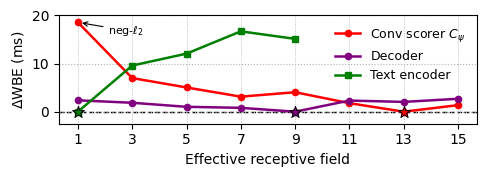

In [34]:
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 10,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

fig, ax_wbe = plt.subplots(
    1,
    1,
    figsize=(5.0, 1.9),
)

style = {
    "Conv scorer": {
        "color": "red",
        "marker": "o",
        "label": r"Conv scorer $C_\psi$",
    },
    "Text encoder": {
        "color": "green",
        "marker": "s",
        "label": "Text encoder",
    },
    "Decoder": {
        "color": "purple",
        "marker": "o",
        "label": "Decoder",
    },
}

for family, group in df.groupby("family"):
    group = group.sort_values("effective_rf")

    ax_wbe.plot(
        group["effective_rf"],
        group["delta_wbe_ms"],
        color=style[family]["color"],
        marker=style[family]["marker"],
        linewidth=1.8,
        markersize=4.5,
        label=style[family]["label"],
        zorder=3,
    )

# Current setting stars:
# Full ND-Aligner uses Conv scorer RF=13, Text encoder RF=1, and Decoder RF=9.
current_settings = [
    ("Conv scorer", 13),
    ("Text encoder", 1),
    ("Decoder", 9),
]

for family, target_rf in current_settings:
    matched = df[(df["family"] == family) & (df["rf"] == target_rf)]

    if matched.empty:
        print(f"[warn] current setting not found: {family}, RF={target_rf}")
        continue

    row = matched.iloc[0]
    x = row["effective_rf"]
    color = style[family]["color"]

    ax_wbe.scatter(
        x,
        row["delta_wbe_ms"],
        marker="*",
        s=80,
        color=color,
        edgecolors="black",
        linewidths=0.7,
        zorder=6,
    )

# Mark RF=1 of Conv scorer as the negative-l2 distance baseline.
neg_l2 = df[(df["family"] == "Conv scorer") & (df["rf"] == 1)]

if neg_l2.empty:
    print("[warn] negative-l2 baseline not found: Conv scorer, RF=1")
else:
    row = neg_l2.iloc[0]
    x = row["effective_rf"]

    ax_wbe.annotate(
        r"neg-$\ell_2$",
        xy=(x, row["delta_wbe_ms"]),
        xytext=(22, -6),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="black",
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8,
            color="black",
            shrinkA=2,
            shrinkB=3,
        ),
        zorder=7,
    )

# Baseline line
ax_wbe.axhline(0.0, color="black", linewidth=1.0, linestyle="--", zorder=1)

# Axis labels
ax_wbe.set_ylabel(r"$\Delta$WBE (ms)")
ax_wbe.set_xlabel("Effective receptive field")

# Limits
ax_wbe.set_ylim(-2.5, 20)

x_min = df["effective_rf"].min()
x_max = df["effective_rf"].max()
ax_wbe.set_xlim(x_min - 0.7, x_max + 0.7)
ax_wbe.set_xticks(sorted(df["effective_rf"].unique()))

ax_wbe.grid(True, axis="y", linestyle=":", linewidth=0.8, zorder=0)
ax_wbe.grid(True, axis="x", linestyle=":", linewidth=0.6, zorder=0)

ax_wbe.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

In [35]:
out_png = BASE_DIR / "rf_ablation.png"
out_pdf = BASE_DIR / "rf_ablation.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")

Saved: /shared/data_zfs/blue2959/ND_Aligner/experiments/v1.4_ablation/test/rf_ablation.png
Saved: /shared/data_zfs/blue2959/ND_Aligner/experiments/v1.4_ablation/test/rf_ablation.pdf
